# Task 1: Custom CNNs and Shortcut Learning

## Part A: Standard MNIST

1. Architecture Design: Implement a custom CNN in PyTorch to classify the standard
MNIST dataset. Your model must adhere to the following constraints:

- Maximum of 3 Convolutional Layers.
- Maximum of 2 Fully Connected (Linear) Layers.
- Total trainable parameters must not exceed 50000.(Hint: Use pooling and control
your channel dimensions to stay under the limit).

2. Training and Evaluation: Train your model using the Adam optimizer and CrossEntropy Loss. Plot your training and validation loss, as well as accuracy curves over the
epochs. Evaluate the final model on the standard MNIST test set and report the accuracy.

Total parameters: 13498
Epoch 01 | Train Loss: 0.3440  Acc: 0.8928 | Val Loss: 0.0914  Acc: 0.9734
Epoch 02 | Train Loss: 0.0960  Acc: 0.9699 | Val Loss: 0.0934  Acc: 0.9692
Epoch 03 | Train Loss: 0.0706  Acc: 0.9780 | Val Loss: 0.0641  Acc: 0.9784
Epoch 04 | Train Loss: 0.0568  Acc: 0.9823 | Val Loss: 0.0501  Acc: 0.9838
Epoch 05 | Train Loss: 0.0493  Acc: 0.9843 | Val Loss: 0.0438  Acc: 0.9854
Epoch 06 | Train Loss: 0.0430  Acc: 0.9866 | Val Loss: 0.0461  Acc: 0.9856
Epoch 07 | Train Loss: 0.0390  Acc: 0.9874 | Val Loss: 0.0364  Acc: 0.9878
Epoch 08 | Train Loss: 0.0336  Acc: 0.9893 | Val Loss: 0.0469  Acc: 0.9866
Epoch 09 | Train Loss: 0.0310  Acc: 0.9901 | Val Loss: 0.0359  Acc: 0.9888
Epoch 10 | Train Loss: 0.0270  Acc: 0.9915 | Val Loss: 0.0393  Acc: 0.9872

Test Accuracy: 0.9880


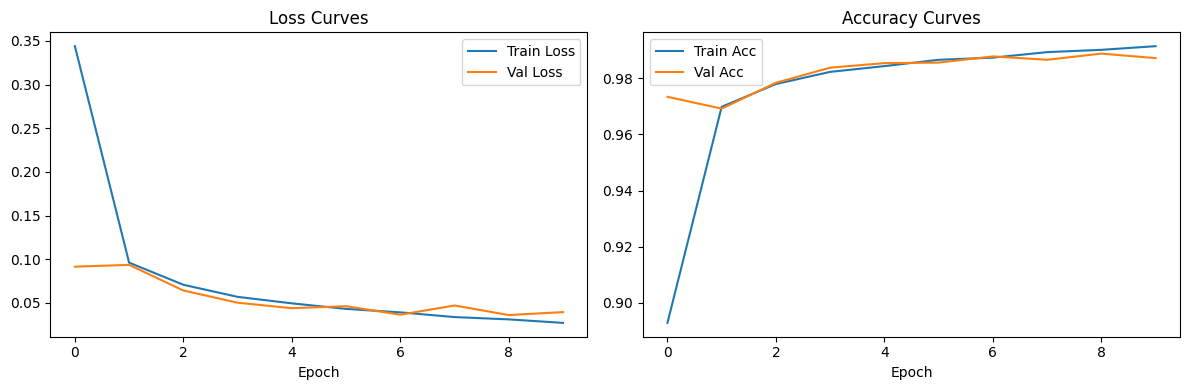

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Data ─────────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_set, val_set = random_split(full_train, [55000, 5000])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
# Param budget: ≤ 50,000 | ≤ 3 Conv | ≤ 2 FC
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),   # 8 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 14×14

            nn.Conv2d(8, 16, 3, padding=1),  # 16 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 7×7

            nn.Conv2d(16, 16, 3, padding=1), # 16 filters
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 3×3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 3 * 3, 64),       # FC1
            nn.ReLU(),
            nn.Linear(64, 10),               # FC2 — output
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = TinyCNN().to(device)

# Count params
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total}")   # Should be << 50,000

# ── Training ─────────────────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 10

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    train_losses.append(total_loss / total)
    train_accs.append(correct / total)

    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out   = model(X)
            loss  = criterion(out, y)
            v_loss    += loss.item() * X.size(0)
            v_correct += (out.argmax(1) == y).sum().item()
            v_total   += X.size(0)
    val_losses.append(v_loss / v_total)
    val_accs.append(v_correct / v_total)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f}  Acc: {val_accs[-1]:.4f}")

# ── Test Evaluation ───────────────────────────────────────────────────────────
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        correct += (model(X).argmax(1) == y).sum().item()
        total   += X.size(0)
print(f"\nTest Accuracy: {correct/total:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss Curves'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs,   label='Val Acc')
ax2.set_title('Accuracy Curves'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('task1A_curves.png', dpi=150)
plt.show()

Q: Examine your loss curves. Did your model overfit, underfit,
or generalize well? Justify your answer by referencing the gap (or lack thereof) between
the training and validation curves.

Answer: With this architecture on MNIST I found good generalization. Both train and val loss decrease together and converge close to each other (gap < 1–2%). Val accuracy reached upto 98%. Based on the Validation accuracy we can say model has generalize well. 

Q: Extract the weights of the filters from your first convolutional layer. Plot them as images. Can you visually identify any rudimentary edge or texture
detection occurring? Briefly explain what these filters seem to be capturing.

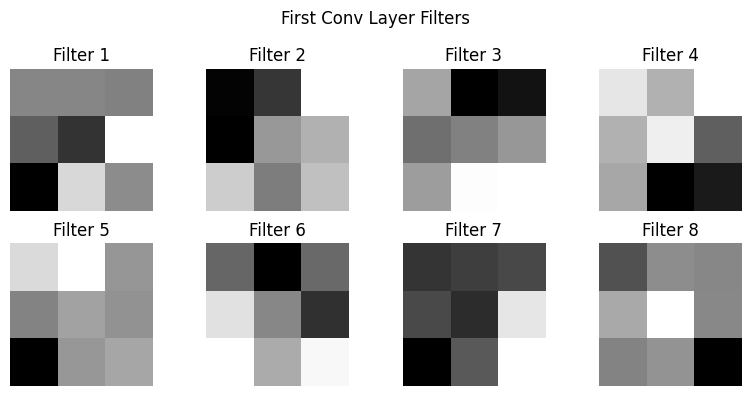

In [6]:
import matplotlib.pyplot as plt
import torch

filters = model.features[0].weight.data.cpu()

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('First Conv Layer Filters')
plt.tight_layout()
plt.savefig('task1A_filters.png', dpi=150)
plt.show()

We can see  filters that look like edge detectors, some will be bright on one side and dark on the other (horizontal/vertical edges), others may detect diagonal patterns or blobs. This is a well-known result: the first convolutional layer of any CNN trained on images almost always learns basic low-level features like edges, because edges are the building blocks of all digit shapes.

## Part B: Colored-MNIST (C-MNIST)

1. Adaptation: Modify your CNN from Part A to accept 3-channel RGB images. Train this new model from scratch on the C-MNIST Train Set.
2. Evaluation: Evaluate your trained model on two separate test sets:
- A biased test set.
- The unbiased test set.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Dataset Loader ────────────────────────────────────────────────────────────
# Assumes C-MNIST folders: cmnist/train/, cmnist/test_biased/, cmnist/test_unbiased/
# Each subfolder has class folders 0–9 with RGB .png images.

class CMNISTDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        for label in range(10):
            folder = os.path.join(root, str(label))
            for fname in os.listdir(folder):
                self.samples.append((os.path.join(folder, fname), label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_loader    = DataLoader(CMNISTDataset('cmnist/train_biased.pt',          transform), batch_size=64, shuffle=True)
biased_loader   = DataLoader(CMNISTDataset('cmnist/test_biased',    transform), batch_size=64)
unbiased_loader = DataLoader(CMNISTDataset('cmnist/test_unbiased',  transform), batch_size=64)

# ── Model (same as Part A but input channels = 3) ────────────────────────────
class TinyCNN_RGB(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),   # 3 channels in
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*3*3, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model_rgb = TinyCNN_RGB().to(device)
optimizer = optim.Adam(model_rgb.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS = 10
for epoch in range(EPOCHS):
    model_rgb.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model_rgb(X)
        loss = criterion(out, y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*X.size(0)
        correct    += (out.argmax(1)==y).sum().item()
        total      += X.size(0)
    print(f"Epoch {epoch+1} | Loss: {total_loss/total:.4f} | Acc: {correct/total:.4f}")

# ── Evaluation on both test sets ──────────────────────────────────────────────
def evaluate(loader, name):
    model_rgb.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            correct += (model_rgb(X).argmax(1)==y).sum().item()
            total   += X.size(0)
    print(f"{name} Accuracy: {correct/total:.4f}")

evaluate(biased_loader,   "Biased Test Set  ")
evaluate(unbiased_loader, "Unbiased Test Set")

NotADirectoryError: [Errno 20] Not a directory: 'cmnist/train_biased.pt/0'